
# EDA — Sistema inteligente de priorización de cobranzas

**Proyecto integrador de Inteligencia Artificial**  
**Tema:** priorización inteligente de cobranzas para empresas que venden a crédito.

Este notebook desarrolla el **Análisis Exploratorio de Datos (EDA)** del proyecto con base en la guía de implementación y la rúbrica entregadas. La estructura cubre:

1. Comprensión del dataset  
2. Revisión de calidad de datos  
3. Estadísticas descriptivas  
4. Análisis de distribuciones  
5. Identificación de outliers  
6. Análisis de correlaciones  
7. Análisis de variables categóricas  
8. Relaciones entre variables  
9. Problemas para el modelado y recomendaciones

## Contexto del sistema

El sistema tiene tres componentes funcionales:

- **Componente 1:** predicción de mora por factura, en clases `on_time`, `+30`, `+60` y `+90`.
- **Componente 2:** segmentación de clientes para asignar estrellas de 1 a 5 según su comportamiento histórico.
- **Componente 3:** decisor de acción de cobranza basado en reglas de negocio.

La **unidad principal de predicción** es la **factura**, pero el dataset de modelado trabaja con **cortes temporales**. Esto significa que una misma factura puede tener varias filas en `features_ml`, una por cada momento de scoring.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'project_paths.py').exists():
            return candidate
    raise FileNotFoundError('No se pudo localizar la raiz del proyecto.')

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from project_paths import GENERATION_DIR, ensure_artifact_dirs

ensure_artifact_dirs()
BASE_DIR = GENERATION_DIR if (GENERATION_DIR / 'features_ml.csv').exists() else ROOT / '01_generacion' / 'data'
print(f'Base de datos EDA: {BASE_DIR}')


Base de datos EDA: C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data


In [3]:

# Localización robusta de archivos
BASE = BASE_DIR


def find_file(*candidates):
    for name in candidates:
        p = BASE / name
        if p.exists():
            return p
    raise FileNotFoundError(f'No se encontró ninguno de estos archivos: {candidates}')

clientes_path  = find_file('clientes_v4.csv', 'clientes.csv')
facturas_path  = find_file('facturas_v4.csv', 'facturas.csv')
gestiones_path = find_file('gestiones_cobranza_v4.csv', 'gestiones_cobranza.csv')
promesas_path  = find_file('promesas_pago_v4.csv', 'promesas_pago.csv')
features_path  = find_file('features_ml_v4.csv', 'features_ml.csv')

clientes  = pd.read_csv(clientes_path)
facturas  = pd.read_csv(facturas_path, parse_dates=['fecha_emision', 'fecha_vencimiento', 'fecha_pago_real'])
gestiones = pd.read_csv(gestiones_path, parse_dates=['fecha_gestion'])
promesas  = pd.read_csv(promesas_path, parse_dates=['fecha_promesa', 'fecha_compromiso'])
features  = pd.read_csv(features_path, parse_dates=['fecha_corte'])

fact_target_col = 'target_mora' if 'target_mora' in facturas.columns else 'estado_pago'

print('Archivos cargados correctamente:')
for p in [clientes_path, facturas_path, gestiones_path, promesas_path, features_path]:
    print('-', p)


Archivos cargados correctamente:
- C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data\clientes.csv
- C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data\facturas.csv
- C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data\gestiones_cobranza.csv
- C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data\promesas_pago.csv
- C:\Users\KevinUbe\Documents\Proyectos\GRUPO_3\GRUPO_3\01_generacion\data\features_ml.csv


## 1. Comprensión del dataset

In [4]:

# Resumen general de datasets
resumen_dataset = pd.DataFrame([
    {'dataset': 'clientes',  'filas': len(clientes),  'columnas': clientes.shape[1]},
    {'dataset': 'facturas',  'filas': len(facturas),  'columnas': facturas.shape[1]},
    {'dataset': 'gestiones', 'filas': len(gestiones), 'columnas': gestiones.shape[1]},
    {'dataset': 'promesas',  'filas': len(promesas),  'columnas': promesas.shape[1]},
    {'dataset': 'features_ml','filas': len(features), 'columnas': features.shape[1]},
])

display(resumen_dataset)


,dataset,filas,columnas
0,clientes,200,6
1,facturas,5338,9
2,gestiones,14333,9
3,promesas,1741,7
4,features_ml,19671,36


In [5]:

# Perfil estructural de cada tabla

def profile_df(df):
    return pd.DataFrame({
        'columna': df.columns,
        'tipo': [str(df[c].dtype) for c in df.columns],
        'nulos': [int(df[c].isna().sum()) for c in df.columns],
        'pct_nulos': [round(df[c].isna().mean()*100, 2) for c in df.columns],
        'unicos': [int(df[c].nunique(dropna=True)) for c in df.columns],
    })

for nombre, df in [('clientes', clientes), ('facturas', facturas), ('gestiones', gestiones), ('promesas', promesas), ('features_ml', features)]:
    display(Markdown(f'### {nombre}'))
    display(profile_df(df))


### clientes

,columna,tipo,nulos,pct_nulos,unicos
0,cliente_id,str,0,0.0000,200
1,nombre,str,0,0.0000,200
2,sector,str,0,0.0000,8
3,antiguedad_meses,int64,0,0.0000,66
4,tiene_garantia,int64,0,0.0000,2
5,perfil_pago,str,0,0.0000,4


### facturas

,columna,tipo,nulos,pct_nulos,unicos
0,factura_id,str,0,0.0000,5338
1,cliente_id,str,0,0.0000,200
2,fecha_emision,datetime64[us],0,0.0000,730
3,fecha_vencimiento,datetime64[us],0,0.0000,784
4,fecha_pago_real,datetime64[us],0,0.0000,831
5,condicion_dias,int64,0,0.0000,4
6,monto,float64,0,0.0000,5337
7,target_mora,str,0,0.0000,4
8,dias_mora_real,int64,0,0.0000,121


### gestiones

,columna,tipo,nulos,pct_nulos,unicos
0,gestion_id,str,0,0.0000,14333
1,factura_id,str,0,0.0000,4221
2,cliente_id,str,0,0.0000,200
3,fecha_gestion,datetime64[us],0,0.0000,884
4,canal,str,0,0.0000,5
5,contacto_exitoso,int64,0,0.0000,2
6,resultado,str,0,0.0000,9
7,motivo_no_pago,str,9283,64.7700,7
8,dias_mora_en_gestion,int64,0,0.0000,121


### promesas

,columna,tipo,nulos,pct_nulos,unicos
0,promesa_id,str,0,0.0000,1741
1,gestion_id,str,0,0.0000,1741
2,factura_id,str,0,0.0000,1405
3,cliente_id,str,0,0.0000,189
4,fecha_promesa,datetime64[us],0,0.0000,704
5,fecha_compromiso,datetime64[us],0,0.0000,714
6,se_cumplio,int64,0,0.0000,2


### features_ml

,columna,tipo,nulos,pct_nulos,unicos
0,factura_id,str,0,0.0000,5338
1,cliente_id,str,0,0.0000,200
2,num_corte,int64,0,0.0000,11
3,fecha_corte,datetime64[us],0,0.0000,900
4,monto,float64,0,0.0000,5337
5,condicion_dias,int64,0,0.0000,4
6,antiguedad_meses,int64,0,0.0000,66
7,tiene_garantia,int64,0,0.0000,2
8,sector_retail,int64,0,0.0000,2
9,sector_manufactura,int64,0,0.0000,2



### Interpretación inicial

- `clientes`, `facturas`, `gestiones_cobranza` y `promesas_pago` conforman el modelo transaccional del problema.
- `features_ml` es el dataset de entrenamiento del componente 1 y trabaja con **cortes temporales**, por lo que tiene más filas que `facturas`.
- En este proyecto, el análisis principal para modelado se realizará sobre `features_ml`, mientras que las tablas base se usan para validar consistencia, trazabilidad y lógica de negocio.


## 2. Revisión de la calidad de los datos

In [6]:

# Duplicados, unicidad e integridad referencial
quality_checks = {
    'clientes_duplicate_rows': int(clientes.duplicated().sum()),
    'facturas_duplicate_rows': int(facturas.duplicated().sum()),
    'gestiones_duplicate_rows': int(gestiones.duplicated().sum()),
    'promesas_duplicate_rows': int(promesas.duplicated().sum()),
    'features_duplicate_rows': int(features.duplicated().sum()),
    'cliente_id_unique': bool(clientes['cliente_id'].is_unique),
    'factura_id_unique': bool(facturas['factura_id'].is_unique),
    'gestion_id_unique': bool(gestiones['gestion_id'].is_unique),
    'promesa_id_unique': bool(promesas['promesa_id'].is_unique),
    'factura_cliente_fk_missing': int((~facturas['cliente_id'].isin(clientes['cliente_id'])).sum()),
    'gestion_factura_fk_missing': int((~gestiones['factura_id'].isin(facturas['factura_id'])).sum()),
    'promesa_gestion_fk_missing': int((~promesas['gestion_id'].isin(gestiones['gestion_id'])).sum()),
    'promesa_factura_fk_missing': int((~promesas['factura_id'].isin(facturas['factura_id'])).sum()),
}

quality_df = pd.DataFrame(quality_checks.items(), columns=['validacion', 'resultado'])
display(quality_df)


,validacion,resultado
0,clientes_duplicate_rows,0
1,facturas_duplicate_rows,0
2,gestiones_duplicate_rows,0
3,promesas_duplicate_rows,0
4,features_duplicate_rows,0
5,cliente_id_unique,True
6,factura_id_unique,True
7,gestion_id_unique,True
8,promesa_id_unique,True
9,factura_cliente_fk_missing,0


In [7]:

# Consistencia temporal
fact_id_num = facturas['factura_id'].str.extract(r'(\d+)').astype(int)
chrono_monotonic = facturas.assign(factura_num=fact_id_num)[['factura_num', 'fecha_emision']].sort_values('factura_num')['fecha_emision'].is_monotonic_increasing

temporal_checks = {
    'fact_venc_before_emision': int((facturas['fecha_vencimiento'] < facturas['fecha_emision']).sum()),
    'fact_pago_before_emision': int((facturas['fecha_pago_real'] < facturas['fecha_emision']).sum()),
    'fact_id_chrono_monotonic': bool(chrono_monotonic),
    'gest_before_emision': int((gestiones.merge(facturas[['factura_id', 'fecha_emision']], on='factura_id', how='left')['fecha_gestion'] <
                                gestiones.merge(facturas[['factura_id', 'fecha_emision']], on='factura_id', how='left')['fecha_emision']).sum()),
}

# Gestiones después del pago real
_tmp = gestiones.merge(facturas[['factura_id', 'fecha_pago_real', 'fecha_vencimiento']], on='factura_id', how='left')
temporal_checks['gest_after_pago'] = int((_tmp['fecha_gestion'] > _tmp['fecha_pago_real']).sum())

# Consistencia de contacto vs resultado
resultados_no_contacto = {'no_contesta', 'numero_invalido', 'cliente_ausente'}
resultados_contacto = {'pagado', 'promesa_de_pago', 'disputa_monto', 'rechazo_pago', 'en_proceso_interno', 'confirma_pago'}

temporal_checks['bad_result_when_no_contact'] = int(((gestiones['contacto_exitoso'] == 0) & (~gestiones['resultado'].isin(resultados_no_contacto))).sum())
temporal_checks['bad_result_when_contact'] = int(((gestiones['contacto_exitoso'] == 1) & (~gestiones['resultado'].isin(resultados_contacto))).sum())

display(pd.DataFrame(temporal_checks.items(), columns=['validacion', 'resultado']))


,validacion,resultado
0,fact_venc_before_emision,0
1,fact_pago_before_emision,0
2,fact_id_chrono_monotonic,True
3,gest_before_emision,0
4,gest_after_pago,0
5,bad_result_when_no_contact,0
6,bad_result_when_contact,0


In [8]:

# Nulos por variable
for nombre, df in [('clientes', clientes), ('facturas', facturas), ('gestiones', gestiones), ('promesas', promesas), ('features_ml', features)]:
    nulos = df.isna().sum().sort_values(ascending=False).reset_index()
    nulos.columns = ['columna', 'nulos']
    nulos['pct_nulos'] = (nulos['nulos'] / len(df) * 100).round(2)
    nulos = nulos[nulos['nulos'] > 0]
    display(Markdown(f'### Nulos en {nombre}'))
    display(nulos if not nulos.empty else pd.DataFrame({'mensaje': ['Sin valores nulos']}))


### Nulos en clientes

,mensaje
0,Sin valores nulos


### Nulos en facturas

,mensaje
0,Sin valores nulos


### Nulos en gestiones

,columna,nulos,pct_nulos
0,motivo_no_pago,9283,64.7700


### Nulos en promesas

,mensaje
0,Sin valores nulos


### Nulos en features_ml

,columna,nulos,pct_nulos
0,dias_desde_ultima_gestion,5338,27.1400
1,ultimo_resultado_enc,5338,27.1400



### Interpretación de calidad

- No deberían existir duplicados ni llaves huérfanas entre las tablas; este bloque verifica esa integridad.
- Los nulos observados en `motivo_no_pago` son **estructurales**, porque esa variable solo aplica cuando hubo contacto exitoso y la factura ya estaba vencida.
- Los nulos de `dias_desde_ultima_gestion` y `ultimo_resultado_enc` en `features_ml` corresponden al **corte 0** de cada factura, donde aún no existe ninguna gestión.
- Si estas validaciones permanecen en cero, el dataset puede considerarse consistente para el modelado y para la narrativa académica del EDA.


## 3. Estadísticas descriptivas

In [9]:

# Estadísticas descriptivas de variables numéricas clave
vars_numericas = [
    'monto', 'condicion_dias', 'antiguedad_meses', 'num_facturas_prev',
    'mora_promedio_hist', 'tasa_cumplimiento', 'ratio_monto',
    'num_gestiones_factura', 'dias_desde_emision', 'dias_hasta_vence',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total'
]

estadisticas = features[vars_numericas].describe().T[['mean', '50%', 'std', 'min', '25%', '75%', 'max']]
display(estadisticas)


,mean,50%,std,min,25%,75%,max
monto,"28,173.4347","14,013.5300","32,780.6822",318.9600,"6,641.3400","36,312.9200","149,413.9900"
condicion_dias,56.9277,60.0000,22.5651,30.0000,45.0000,90.0000,90.0000
antiguedad_meses,36.4463,36.0000,18.3374,3.0000,22.0000,51.0000,72.0000
num_facturas_prev,16.1527,14.0000,11.2524,0.0000,7.0000,24.0000,47.0000
mora_promedio_hist,23.9243,18.8900,20.9012,0.0000,3.7500,42.1400,119.0000
tasa_cumplimiento,0.4251,0.3636,0.3858,0.0000,0.0000,0.8000,1.0000
ratio_monto,1.0882,1.0000,0.8361,0.0258,0.5587,1.4885,22.8089
num_gestiones_factura,2.3054,2.0000,2.3321,0.0000,0.0000,4.0000,10.0000
dias_desde_emision,55.8724,54.0000,48.1321,0.0000,0.0000,93.0000,210.0000
dias_hasta_vence,1.0554,-6.0000,46.1046,-120.0000,-30.0000,33.0000,90.0000



### Interpretación descriptiva

- `monto` tiende a presentar asimetría positiva, por lo que la media suele ser bastante mayor que la mediana.
- `condicion_dias` está acotada a un catálogo discreto de créditos: 30, 45, 60 y 90 días.
- Variables como `mora_promedio_hist`, `num_promesas_rotas` y `promesas_total` reflejan historial acumulado y son candidatas naturales para explicar el riesgo.
- `dias_hasta_vence` puede tomar valores negativos, lo cual es correcto, ya que existen cortes posteriores al vencimiento.


## 4. Análisis de distribuciones

In [10]:

# Distribución del target final por factura y por cortes temporales
fact_target = facturas[fact_target_col].value_counts().rename_axis(fact_target_col).reset_index(name='count')
fact_target['pct'] = (fact_target['count'] / len(facturas) * 100).round(2)

feat_target = features['target'].value_counts().rename_axis('target').reset_index(name='count')
feat_target['pct'] = (feat_target['count'] / len(features) * 100).round(2)

print('Distribución del target en facturas:')
display(fact_target)
print('Distribución del target en features_ml:')
display(feat_target)


Distribución del target en facturas:


,target_mora,count,pct
0,on_time,2217,41.5300
1,+30,1246,23.3400
2,+60,1088,20.3800
3,+90,787,14.7400


Distribución del target en features_ml:


,target,count,pct
0,+90,6676,33.9400
1,+60,5965,30.3200
2,+30,3713,18.8800
3,on_time,3317,16.8600


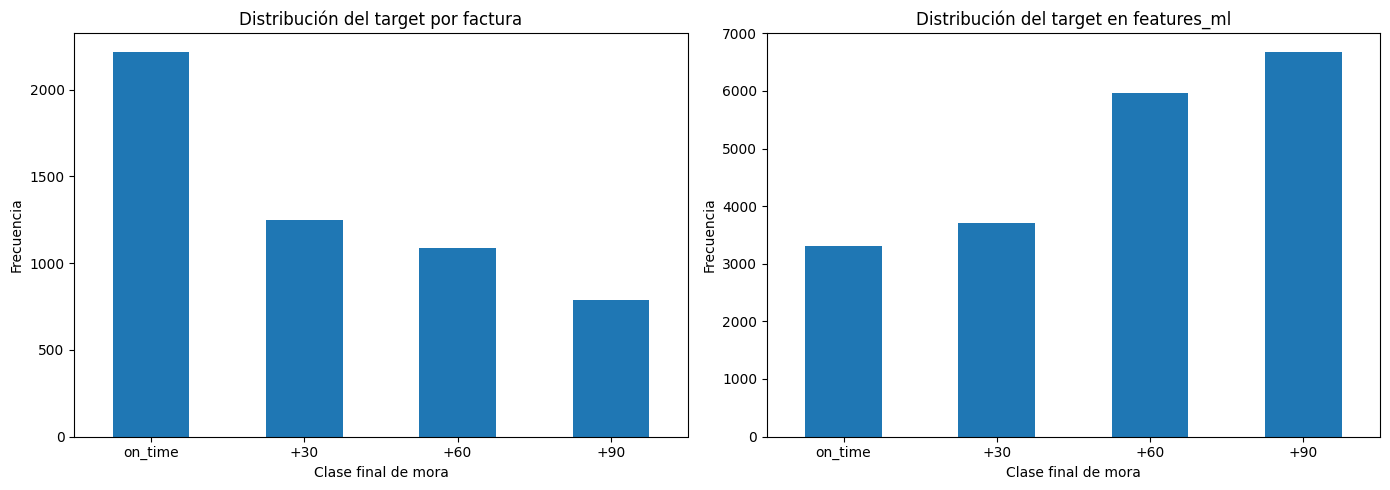

In [11]:

# Gráficos de distribución principales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

facturas[fact_target_col].value_counts().reindex(['on_time', '+30', '+60', '+90']).plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución del target por factura')
axes[0].set_xlabel('Clase final de mora')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

features['target'].value_counts().reindex(['on_time', '+30', '+60', '+90']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribución del target en features_ml')
axes[1].set_xlabel('Clase final de mora')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


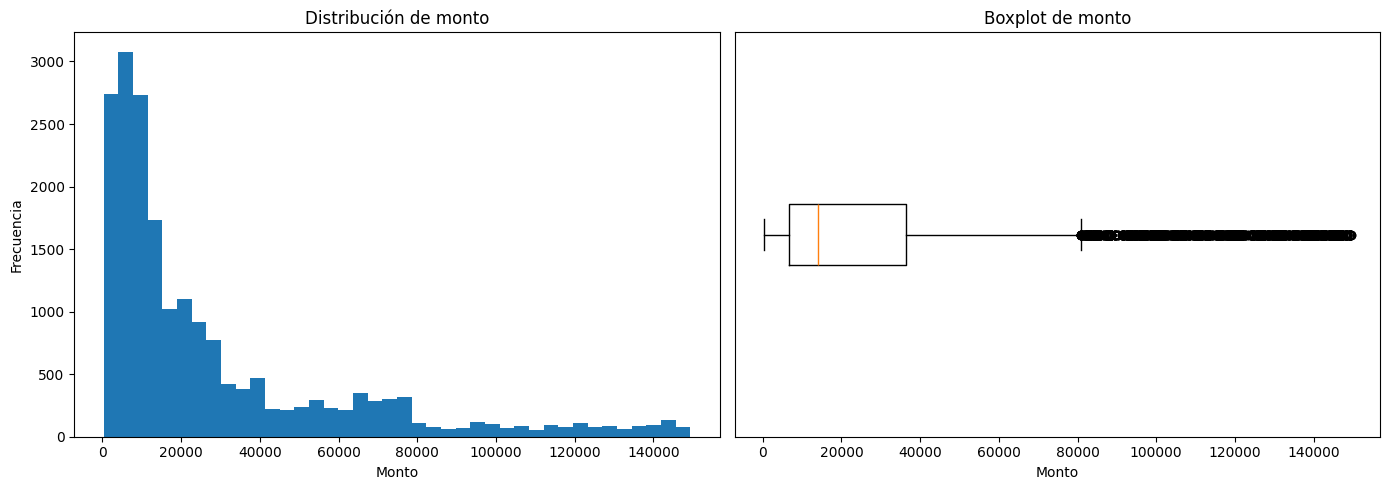

In [12]:

# Histograma y boxplot para monto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features['monto'].dropna(), bins=40)
axes[0].set_title('Distribución de monto')
axes[0].set_xlabel('Monto')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(features['monto'].dropna(), vert=False)
axes[1].set_title('Boxplot de monto')
axes[1].set_xlabel('Monto')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()



### Interpretación de distribuciones

- El `target` debe revisarse tanto a nivel de factura como a nivel de `features_ml`, porque el segundo dataset replica facturas en múltiples cortes.
- Si las clases severas (`+60`, `+90`) aparecen sobrerrepresentadas en `features_ml`, eso no necesariamente implica error: suele deberse a que las facturas más problemáticas generan más gestiones y más cortes.
- La distribución de `monto` debe observarse con cuidado porque influye directamente en priorización y porque puede introducir valores extremos plausibles de negocio.


## 5. Identificación de valores atípicos (Outliers)

In [13]:

# Detección de outliers por IQR
vars_outliers = [
    'monto', 'monto_promedio_hist', 'ratio_monto', 'mora_promedio_hist',
    'mora_ultimo_tramo', 'tasa_cumplimiento', 'num_facturas_prev',
    'moras_consecutivas', 'num_gestiones_factura', 'dias_desde_emision',
    'dias_hasta_vence', 'tasa_contacto_cliente', 'num_no_contesta_cons',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total'
]

outlier_rows = []
for col in vars_outliers:
    q1 = features[col].quantile(0.25)
    q3 = features[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (features[col] < low) | (features[col] > high)
    outlier_rows.append({
        'variable': col,
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(mask.mean() * 100, 2)
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values(['pct_outliers', 'n_outliers'], ascending=False)
display(outliers_df)


,variable,n_outliers,pct_outliers
11,tasa_contacto_cliente,1598,8.1200
0,monto,1551,7.8800
13,num_promesas_rotas,951,4.8300
12,num_no_contesta_cons,916,4.6600
7,moras_consecutivas,670,3.4100
15,promesas_total,541,2.7500
2,ratio_monto,292,1.4800
1,monto_promedio_hist,194,0.9900
4,mora_ultimo_tramo,81,0.4100
3,mora_promedio_hist,38,0.1900


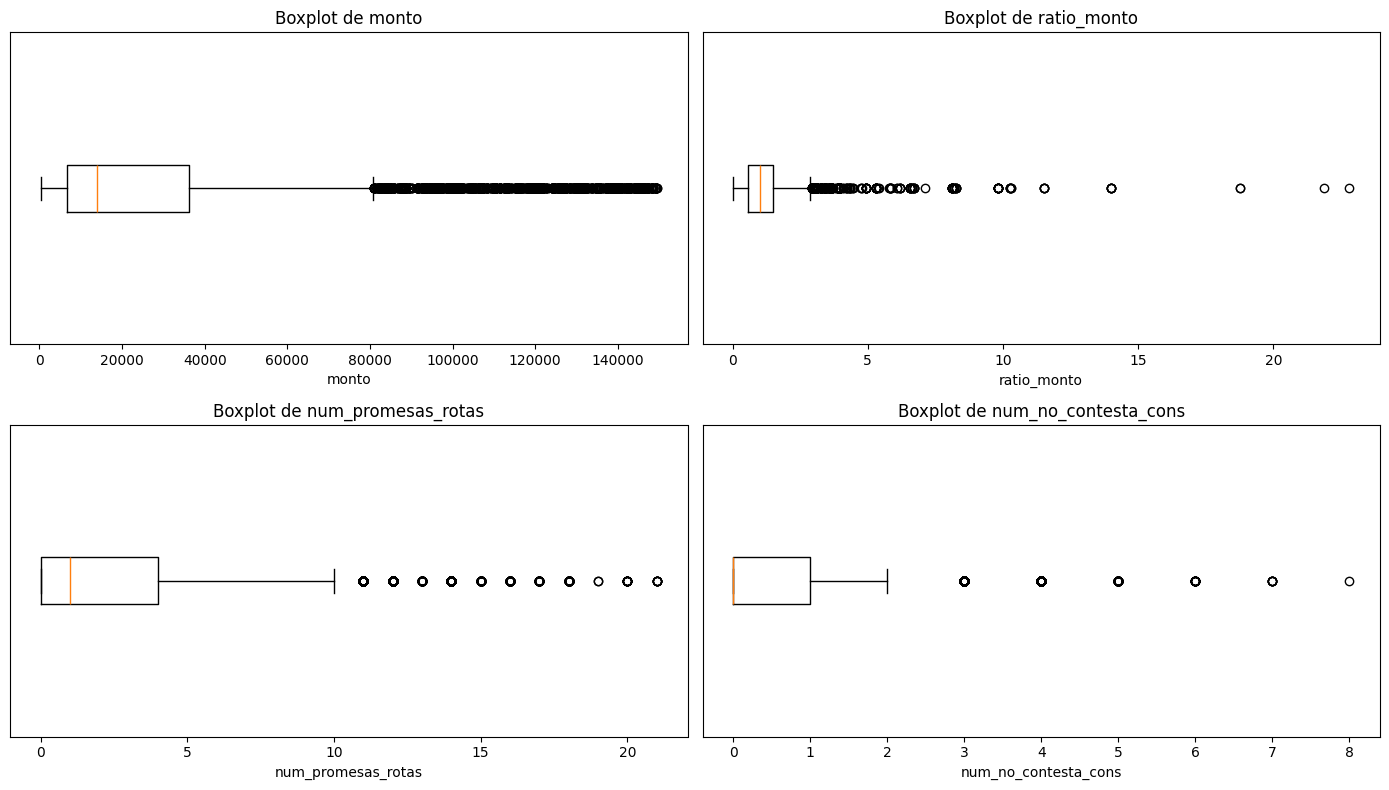

In [14]:

# Boxplots de variables seleccionadas con mayor interés
seleccion_box = ['monto', 'ratio_monto', 'num_promesas_rotas', 'num_no_contesta_cons']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.ravel(), seleccion_box):
    ax.boxplot(features[col].dropna(), vert=False)
    ax.set_title(f'Boxplot de {col}')
    ax.set_xlabel(col)
    ax.set_yticks([])

plt.tight_layout()
plt.show()



### Interpretación de outliers

- La presencia de outliers no implica automáticamente error de captura.
- En este problema, variables como `monto`, `ratio_monto`, `num_promesas_rotas` o `num_no_contesta_cons` pueden contener casos extremos **reales y valiosos** para el modelo.
- Por tanto, la decisión metodológica recomendada es **no eliminarlos de forma automática**. Lo apropiado es documentarlos y, si se entrena un modelo sensible a escala, aplicar transformaciones o escalado robusto.


## 6. Análisis de correlaciones

In [15]:

# Correlación de variables numéricas y con target ordinal
map_target = {'on_time': 0, '+30': 1, '+60': 2, '+90': 3}
features_corr = features.copy()
features_corr['target_ord'] = features_corr['target'].map(map_target)

num_cols = features_corr.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = features_corr[num_cols].corr()

top_corr_target = correlation_matrix['target_ord'].drop('target_ord').sort_values(key=np.abs, ascending=False).head(15)
display(top_corr_target.to_frame('corr'))


,corr
num_corte,0.5709
num_gestiones_factura,0.5709
dias_hasta_vence,-0.5670
dias_desde_emision,0.5543
tasa_cumplimiento,-0.4050
mora_promedio_hist,0.3856
mora_ultimo_tramo,0.3548
tasa_cumpl_promesas,-0.3042
num_promesas_rotas,0.2681
tiene_garantia,-0.2566


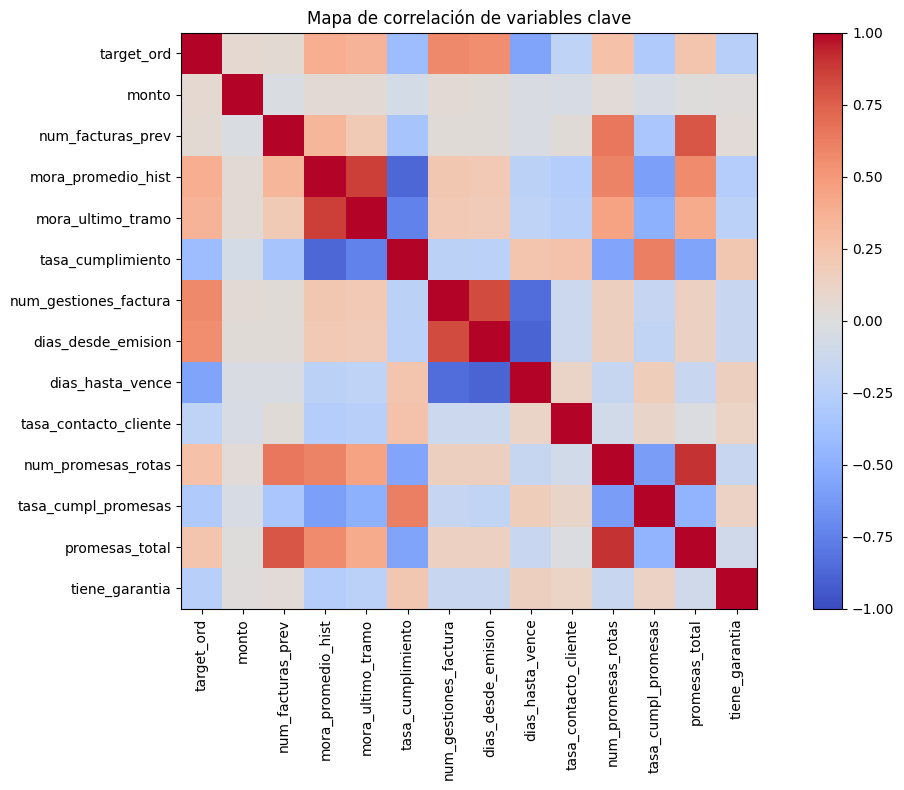

In [16]:

# Heatmap de correlación en variables clave
cols_heatmap = [
    'target_ord', 'monto', 'num_facturas_prev', 'mora_promedio_hist',
    'mora_ultimo_tramo', 'tasa_cumplimiento', 'num_gestiones_factura',
    'dias_desde_emision', 'dias_hasta_vence', 'tasa_contacto_cliente',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total',
    'tiene_garantia'
]

corr_show = features_corr[cols_heatmap].corr()
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(corr_show, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_show.columns)))
ax.set_xticklabels(corr_show.columns, rotation=90)
ax.set_yticks(range(len(corr_show.index)))
ax.set_yticklabels(corr_show.index)
ax.set_title('Mapa de correlación de variables clave')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [17]:

# Pares de alta correlación entre predictores
pred_cols = [c for c in num_cols if c != 'target_ord']
corr_pred = features_corr[pred_cols].corr().abs()
mask = np.triu(np.ones_like(corr_pred, dtype=bool), k=1)
high_pairs = (
    corr_pred.where(mask)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)

display(high_pairs.head(15))


,var1,var2,abs_corr
20,num_corte,num_gestiones_factura,1.0000
959,num_promesas_rotas,promesas_total,0.9045
727,dias_desde_emision,dias_hasta_vence,0.8862
464,mora_promedio_hist,tasa_cumplimiento,0.8687
463,mora_promedio_hist,mora_ultimo_tramo,0.8595
663,num_gestiones_factura,dias_hasta_vence,0.8465
23,num_corte,dias_hasta_vence,0.8465
273,sector_construccion,monto_promedio_hist,0.8319
662,num_gestiones_factura,dias_desde_emision,0.8226
22,num_corte,dias_desde_emision,0.8226



### Interpretación de correlaciones

- Las correlaciones con `target_ord` ayudan a identificar variables con mayor señal explicativa del riesgo.
- Correlaciones muy altas entre predictores sugieren **redundancia** y deben tenerse en cuenta antes del entrenamiento, especialmente si se usará Regresión Logística Multinomial.
- En modelos basados en árboles la multicolinealidad suele ser menos problemática, pero igual conviene documentarla porque afecta interpretación y diseño del pipeline.


## 7. Análisis de variables categóricas

In [18]:

# Frecuencias categóricas

def freq_table(series):
    tab = series.value_counts(dropna=False).rename_axis(series.name).reset_index(name='count')
    tab['pct'] = (tab['count'] / len(series) * 100).round(2)
    return tab

for titulo, serie in [
    ('Sector de clientes', clientes['sector']),
    ('Perfil de pago', clientes['perfil_pago']),
    ('Canal de gestión', gestiones['canal']),
    ('Resultado de gestión', gestiones['resultado']),
    ('Target por factura', facturas[fact_target_col]),
    ('Target en features_ml', features['target'])
]:
    display(Markdown(f'### {titulo}'))
    display(freq_table(serie))


### Sector de clientes

,sector,count,pct
0,construccion,35,17.5000
1,manufactura,34,17.0000
2,salud,27,13.5000
3,agro,24,12.0000
4,transporte,24,12.0000
5,retail,21,10.5000
6,tecnologia,18,9.0000
7,servicios,17,8.5000


### Perfil de pago

,perfil_pago,count,pct
0,regular,78,39.0000
1,excelente,56,28.0000
2,riesgoso,47,23.5000
3,critico,19,9.5000


### Canal de gestión

...

,resultado,count,pct
0,no_contesta,5010,34.9500
1,promesa_de_pago,1741,12.1500
2,rechazo_pago,1592,11.1100
3,en_proceso_interno,1403,9.7900
4,disputa_monto,1294,9.0300
5,cliente_ausente,1242,8.6700
6,confirma_pago,1098,7.6600
7,pagado,509,3.5500
8,numero_invalido,444,3.1000


### Target por factura

,target_mora,count,pct
0,on_time,2217,41.5300
1,+30,1246,23.3400
2,+60,1088,20.3800
3,+90,787,14.7400


### Target en features_ml

,target,count,pct
0,+90,6676,33.9400
1,+60,5965,30.3200
2,+30,3713,18.8800
3,on_time,3317,16.8600


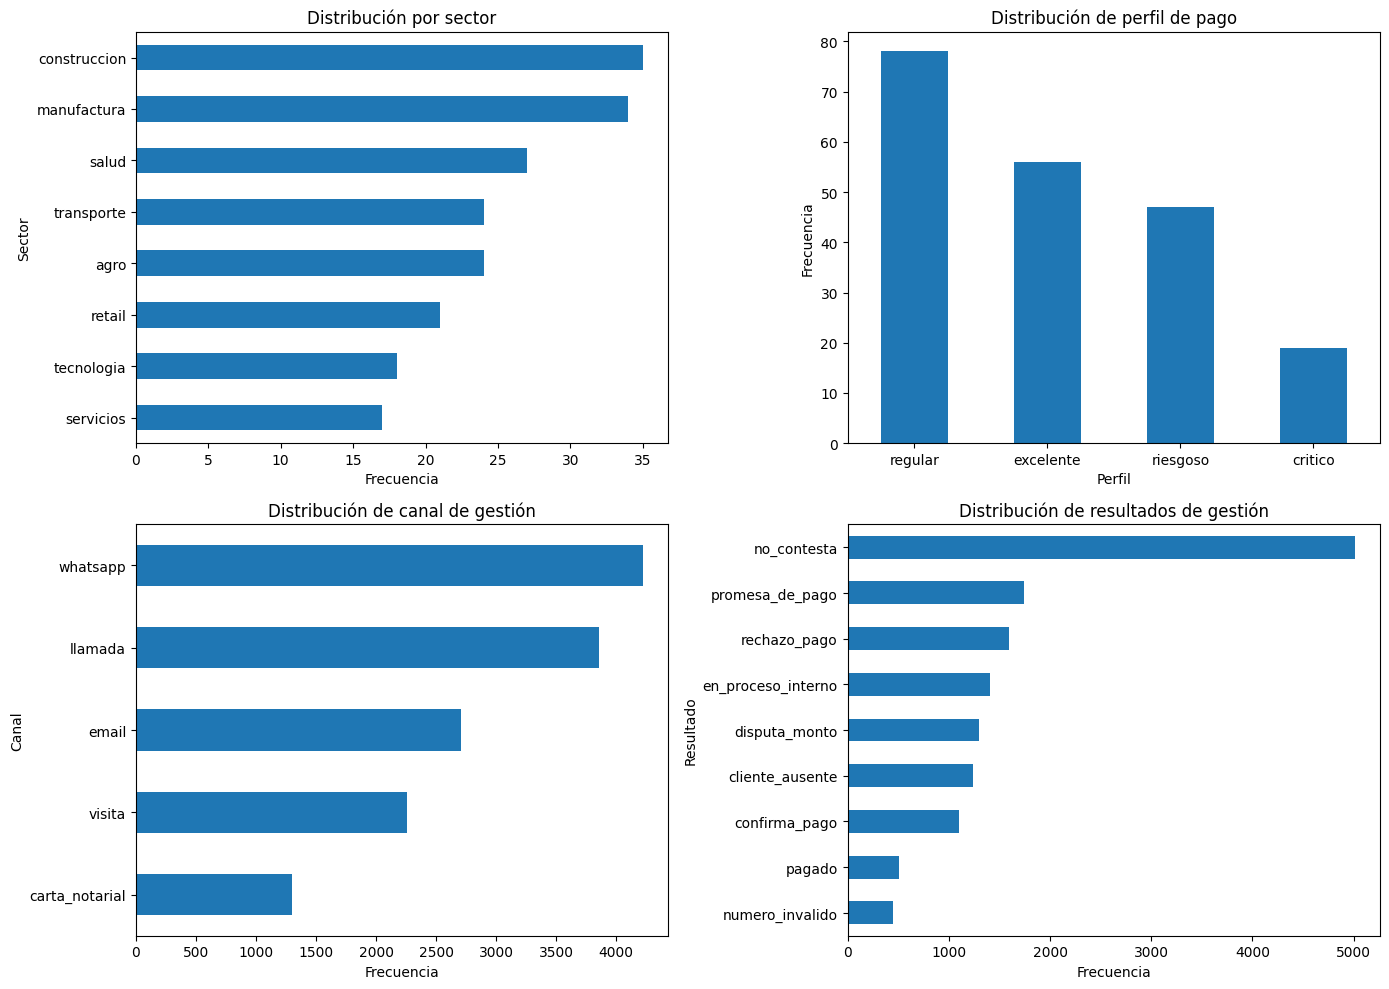

In [19]:

# Gráficos de variables categóricas principales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

clientes['sector'].value_counts().sort_values().plot(kind='barh', ax=axes[0, 0])
axes[0, 0].set_title('Distribución por sector')
axes[0, 0].set_xlabel('Frecuencia')
axes[0, 0].set_ylabel('Sector')

clientes['perfil_pago'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de perfil de pago')
axes[0, 1].set_xlabel('Perfil')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=0)

gestiones['canal'].value_counts().sort_values().plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de canal de gestión')
axes[1, 0].set_xlabel('Frecuencia')
axes[1, 0].set_ylabel('Canal')

gestiones['resultado'].value_counts().sort_values().plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de resultados de gestión')
axes[1, 1].set_xlabel('Frecuencia')
axes[1, 1].set_ylabel('Resultado')

plt.tight_layout()
plt.show()



### Interpretación de categóricas

- Las variables categóricas son esenciales porque describen segmentos de negocio, estrategias de contacto y distribución de clases.
- En este proyecto, la distribución del `target` es especialmente importante porque el problema principal es de clasificación multiclase.
- Si existe desbalance, eso debe quedar documentado aquí y luego retomarse en la etapa de modelado.


## 8. Relaciones entre variables

In [20]:

# Relación target vs garantía
rel_garantia = pd.crosstab(facturas['tiene_garantia'] if 'tiene_garantia' in facturas.columns else facturas.merge(clientes[['cliente_id','tiene_garantia']], on='cliente_id', how='left')['tiene_garantia'],
                           facturas[fact_target_col], normalize='index').round(3)
display(Markdown('### Target por garantía'))
display(rel_garantia)


### Target por garantía

target_mora,+30,+60,+90,on_time
tiene_garantia,,,,
0,0.2530,0.2460,0.1980,0.3040
1,0.2050,0.1440,0.0750,0.5760


In [21]:

# Relación target vs perfil del cliente
facturas_ext = facturas.merge(clientes[['cliente_id', 'perfil_pago', 'sector', 'tiene_garantia']], on='cliente_id', how='left')
rel_perfil = pd.crosstab(facturas_ext['perfil_pago'], facturas_ext[fact_target_col], normalize='index').round(3)
rel_condicion = pd.crosstab(facturas['condicion_dias'], facturas[fact_target_col], normalize='index').round(3)
rel_contacto = pd.crosstab(gestiones['contacto_exitoso'], gestiones['resultado'], normalize='index').round(3)

display(Markdown('### Target por perfil de pago'))
display(rel_perfil)

display(Markdown('### Target por condición de pago'))
display(rel_condicion)

display(Markdown('### Resultado de gestión según contacto exitoso'))
display(rel_contacto)


### Target por perfil de pago

target_mora,+30,+60,+90,on_time
perfil_pago,,,,
critico,0.1850,0.3460,0.4390,0.0300
excelente,0.0910,0.0460,0.0120,0.8500
regular,0.2960,0.1950,0.0870,0.4230
riesgoso,0.3180,0.3480,0.2920,0.0420


### Target por condición de pago

target_mora,+30,+60,+90,on_time
condicion_dias,,,,
30,0.2400,0.2170,0.1400,0.4040
45,0.2220,0.2090,0.1460,0.4220
60,0.2370,0.1820,0.1470,0.4350
90,0.2340,0.2080,0.1570,0.4020


### Resultado de gestión según contacto exitoso

resultado,cliente_ausente,confirma_pago,disputa_monto,en_proceso_interno,no_contesta,numero_invalido,pagado,promesa_de_pago,rechazo_pago
contacto_exitoso,,,,,,,,,
0,0.1850,0.0000,0.0000,0.0000,0.7480,0.0660,0.0000,0.0000,0.0000
1,0.0000,0.1440,0.1690,0.1840,0.0000,0.0000,0.0670,0.2280,0.2080


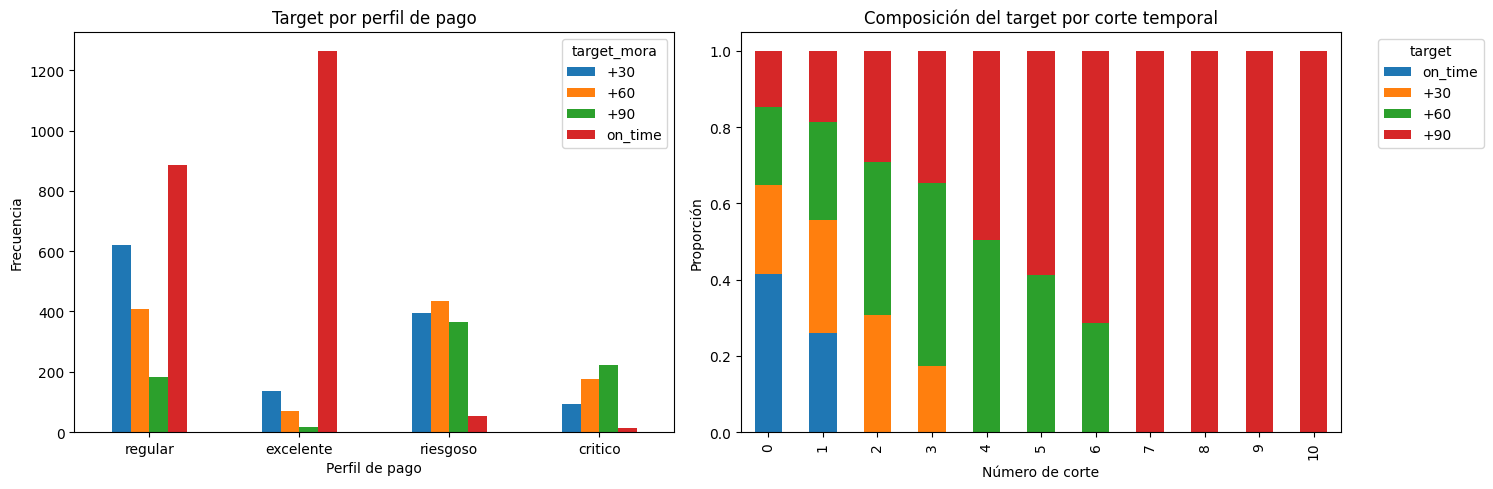

In [22]:

# Relaciones visuales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(facturas_ext['perfil_pago'], facturas_ext[fact_target_col]).reindex(facturas_ext['perfil_pago'].value_counts().index).plot(kind='bar', ax=axes[0])
axes[0].set_title('Target por perfil de pago')
axes[0].set_xlabel('Perfil de pago')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title=fact_target_col)
axes[0].tick_params(axis='x', rotation=0)

orden_corte = sorted(features['num_corte'].dropna().unique())
target_por_corte = pd.crosstab(features['num_corte'], features['target'], normalize='index').reindex(orden_corte)
target_por_corte[['on_time', '+30', '+60', '+90']].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Composición del target por corte temporal')
axes[1].set_xlabel('Número de corte')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='target', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



### Lectura de relaciones

- La relación entre `perfil_pago` y `target_mora` sirve para validar si la simulación es coherente con la lógica de negocio.
- La relación entre `num_corte` y `target` permite observar si el riesgo se deteriora conforme avanza el ciclo de cobranza.
- El cruce entre `contacto_exitoso` y `resultado` es una validación operativa importante: ayuda a verificar que el catálogo de resultados sea consistente.


## 9. Identificación de problemas para el modelado

In [23]:

# Resumen de problemas y decisiones metodológicas
problemas_modelado = pd.DataFrame([
    {
        'problema_detectado': 'Desbalance de clases en features_ml',
        'evidencia': f"+60 y +90 representan {((features['target'].isin(['+60', '+90'])).mean()*100):.2f}% de las filas",
        'impacto': 'Puede sesgar el entrenamiento y favorecer clases mayoritarias',
        'recomendacion': 'Usar F1-macro como métrica principal y evaluar class_weight o balanceo'
    },
    {
        'problema_detectado': 'Redundancia entre variables temporales y de gestión',
        'evidencia': 'num_corte y num_gestiones_factura suelen estar perfectamente correlacionadas',
        'impacto': 'Aumenta redundancia y dificulta interpretación',
        'recomendacion': 'Conservar solo una de las dos en la primera iteración de modelado'
    },
    {
        'problema_detectado': 'Nulos estructurales en corte 0',
        'evidencia': 'dias_desde_ultima_gestion y ultimo_resultado_enc no aplican antes de la primera gestión',
        'impacto': 'Exige estrategia explícita de imputación o indicador de ausencia',
        'recomendacion': 'Imputar con valor neutral y/o agregar indicador binario de ausencia'
    },
    {
        'problema_detectado': 'Outliers plausibles de negocio',
        'evidencia': 'monto, ratio_monto y num_promesas_rotas muestran valores extremos',
        'impacto': 'Pueden influir en modelos sensibles a escala',
        'recomendacion': 'No eliminar automáticamente; usar escalado robusto si es necesario'
    },
    {
        'problema_detectado': 'Múltiples filas por factura',
        'evidencia': 'features_ml contiene cortes temporales por factura',
        'impacto': 'Existe riesgo de fuga si el split se hace por fila',
        'recomendacion': 'Dividir train/test por factura_id, no por fila'
    },
])

display(problemas_modelado)


,problema_detectado,evidencia,impacto,recomendacion
0,Desbalance de clases en features_ml,+60 y +90 representan 64.26% de las filas,Puede sesgar el entrenamiento y favorecer clas...,Usar F1-macro como métrica principal y evaluar...
1,Redundancia entre variables temporales y de ge...,num_corte y num_gestiones_factura suelen estar...,Aumenta redundancia y dificulta interpretación,Conservar solo una de las dos en la primera it...
2,Nulos estructurales en corte 0,dias_desde_ultima_gestion y ultimo_resultado_e...,Exige estrategia explícita de imputación o ind...,Imputar con valor neutral y/o agregar indicado...
3,Outliers plausibles de negocio,"monto, ratio_monto y num_promesas_rotas muestr...",Pueden influir en modelos sensibles a escala,No eliminar automáticamente; usar escalado rob...
4,Múltiples filas por factura,features_ml contiene cortes temporales por fac...,Existe riesgo de fuga si el split se hace por ...,"Dividir train/test por factura_id, no por fila"



## 10. Conclusiones del EDA

1. El dataset presenta una **estructura consistente** entre tablas y una lógica temporal adecuada para el problema.
2. `features_ml` es el dataset correcto para entrenar el componente 1, ya que representa el **scoring dinámico por cortes**.
3. Existen **nulos estructurales**, no necesariamente errores, y deben tratarse explícitamente en el pipeline.
4. Se identifican **outliers plausibles de negocio** que no deben eliminarse sin justificación.
5. Hay **señales útiles para el modelado**, pero también redundancias y posibles problemas de multicolinealidad.
6. El EDA confirma que el siguiente paso debe ser construir un pipeline reproducible de limpieza/preprocesamiento y luego ejecutar el comparativo experimental de algoritmos.



## 11. Recomendaciones para la siguiente fase

- Trabajar el entrenamiento con `features_ml`.
- Realizar la partición de entrenamiento y prueba por `factura_id`.
- Imputar nulos estructurales de forma explícita.
- Evaluar eliminación de variables redundantes antes de entrenar la Regresión Logística Multinomial.
- Mantener `F1-macro` como métrica principal por la distribución observada de clases.
- Documentar el pipeline en este orden: datos crudos → limpieza → selección/transformación de variables → balanceo si aplica → dataset listo para entrenamiento.



## 12. Referencias de contexto metodológico

Este notebook se alinea con la guía y la rúbrica entregadas para el EDA. En el **reporte académico posterior** se debe incorporar la redacción formal, discusión ampliada y referencias bibliográficas en formato APA, tal como exige la evaluación.
